# Amazon Sales Dataset - 고객 등급별 세부 분석
## RFM 기반 멤버십 등급 분석 | Silver + Bronze
---
## 📋 분석 개요

본 분석은 RFM 세그먼테이션을 통해 도출된 등급 중 **재방문율이 가장 낮은 Silver와 Bronze** 를 대상으로,
소수의 재구매 고객과 1회 구매 고객 간의 차이를 비교 분석하여 재구매 유도 전략을 도출한다.

| 항목 | 내용 |
|------|------|
| 분석 대상 | Silver + Bronze (이탈 위험 고객군) |
| 분석 기간 | 2023-12-29 ~ 2024-12-29 |
| Silver | 3,900명 (23.67%) / 재방문율 11.2% |
| Bronze | 4,168명 (25.29%) / 재방문율 3.5% |
| 합계 | 8,068명 (49.0%) |

---

## 📊 분석 방향

Silver와 Bronze는 전체 고객의 49.0%를 차지하지만 매출 기여도는 합산 38.9%에 그친다.
재구매율이 극히 낮은 이 그룹 내에서도 **소수의 재구매 고객이 존재**한다는 점에 주목하여,
재구매 고객과 1회 구매 고객 간의 차이를 역으로 분석함으로써 재구매 유도 조건을 탐색한다.

---

## 💡 가설

> **가설 1**: Silver/Bronze 내 재구매 고객은 1회 구매 고객보다 첫 구매 시 할인율이 낮을 것이다.
>
> 할인에 의존한 첫 구매는 브랜드 또는 플랫폼에 대한 본질적인 관심보다 가격 민감도에서 비롯될 가능성이 높다.
> 따라서 할인율이 높을수록 재구매로 이어지지 않는다는 가설을 검증한다.
---
> **가설 2**: Silver/Bronze 내 재구매 고객은 1회 구매 고객과 첫 구매 카테고리 분포가 다를 것이다.
>
> 카테고리에 따라 재구매 가능성이 다르며, 재구매가 일어난 카테고리에서 유효한 진입점을 찾을 수 있다.
> 이를 통해 재구매를 유도하기 위한 첫 구매 카테고리 전략을 제언한다.
---
> **가설 3**: Silver/Bronze 내 재구매 고객은 1회 구매 고객보다 첫 구매 시 객단가가 높을 것이다.
>
> 첫 구매 금액이 클수록 플랫폼에 대한 신뢰나 만족도가 높아 재구매로 이어질 가능성이 있다.
> 이를 통해 첫 구매 금액과 재구매 여부 간의 관계를 검증한다.

---


In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from dotenv import load_dotenv
import os

load_dotenv()  # .env 파일 로드

# MySQL 연결
engine = create_engine(
    f"mysql+mysqlconnector://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}/{os.getenv('DB_NAME')}"
)


In [2]:
# Bronze/Silver 등급 고객 테이블 + 재구매 고객인지 아닌지 분류
query="""
SELECT
    o.*,
    r.Grade,
    COUNT(o.OrderID) OVER (PARTITION BY o.CustomerID) AS Frequency
FROM orders_info o
JOIN rfm_result r ON r.CustomerID = o.CustomerID
WHERE r.Grade IN ('Silver', 'Bronze')
    AND o.OrderDate >= DATE_SUB('2024-12-29', INTERVAL 1 YEAR)
    AND o.OrderDate <= '2024-12-29'
ORDER BY o.CustomerID;
"""

df_sb = pd.read_sql(query, engine)

In [3]:
df_sb.head()

,OrderID,OrderDate,CustomerID,ProductID,Category,Brand,Discount,TotalAmount,PaymentMethod,Grade,Frequency
0,ORD0085393,2024-07-26,CUST000001,P00025,Home & Kitchen,BrightLux,0.10,446.48,Cash on Delivery,Silver,1
1,ORD0022455,2024-06-17,CUST000004,P00039,Electronics,NexPro,0.10,583.70,Credit Card,Silver,1
2,ORD0035087,2024-04-25,CUST000006,P00031,Books,Zenith,0.10,818.42,Credit Card,Silver,1
3,ORD0008412,2024-04-16,CUST000009,P00033,Clothing,CoreTech,0.15,26.00,Net Banking,Bronze,1
4,ORD0093703,2023-12-31,CUST000021,P00008,Toys & Games,Zenith,0.00,2253.82,Credit Card,Bronze,1


In [4]:
df_sb.shape

(8672, 11)

In [5]:
df_sb.describe()

,OrderDate,Discount,TotalAmount,Frequency
count,8672,8672.000000,8672.000000,8672.000000
mean,2024-04-08 12:39:01.328413440,0.074798,821.906143,1.144142
min,2023-12-29 00:00:00,0.000000,6.190000,1.000000
25%,2024-02-16 00:00:00,0.000000,297.215000,1.000000
50%,2024-04-05 00:00:00,0.050000,595.635000,1.000000
75%,2024-05-24 00:00:00,0.150000,1171.487500,1.000000
max,2024-08-18 00:00:00,0.300000,3511.950000,3.000000
std,NaN,0.082795,691.978593,0.371363


In [6]:
df_sb['CustomerID'].nunique()

8068

In [7]:
# 재구매 여부 태깅
df_sb['customer_type'] = df_sb['Frequency'].apply(
    lambda x: '재구매 고객' if x >= 2 else '1회 구매 고객'
)

# 고객 단위로 집계 (주문 행 중복 제거)
df_sb_customers = df_sb.drop_duplicates(subset='CustomerID')[['CustomerID', 'Grade', 'Frequency', 'customer_type']]

In [8]:
df_sb_customers['customer_type'].value_counts()

customer_type
1회 구매 고객    7485
재구매 고객       583
Name: count, dtype: int64

In [9]:
# 고객별 첫 구매 행 추출 (OrderDate 기준 정렬 후 첫 행)
df_sb_first = (
    df_sb.sort_values('OrderDate')
    .groupby('CustomerID')
    .first()
    .reset_index()
)

In [10]:
# 재구매 고객 vs 1회 구매 고객 첫 구매 할인율 비교
discount_compare = df_sb_first.groupby('customer_type')['Discount'].mean().reset_index()
discount_compare.columns = ['customer_type', 'avg_discount']

In [11]:
discount_compare

,customer_type,avg_discount
0,1회 구매 고객,0.075458
1,재구매 고객,0.070926


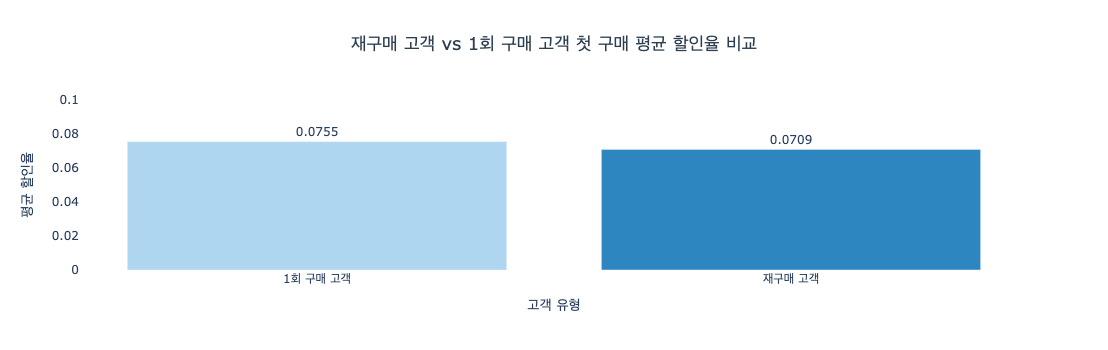

In [12]:
fig = go.Figure(go.Bar(
    x=discount_compare['customer_type'],
    y=discount_compare['avg_discount'],
    marker_color=['#AED6F1', '#2E86C1'],
    text=discount_compare['avg_discount'].apply(lambda x: f'{x:.4f}'),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='재구매 고객 vs 1회 구매 고객 첫 구매 평균 할인율 비교',
        font=dict(size=18, color='#2c3e50'),
        x=0.5,
        xanchor='center'
    ),
    yaxis=dict(
        title='평균 할인율',
        range=[0, 0.1]
    ),
    xaxis=dict(title='고객 유형'),
    plot_bgcolor='white',
    height=350,
    width=500
)

fig.show()

### 재구매 고객 vs 1회 구매 고객 첫 구매 할인율 비교

**가설 1**: Silver/Bronze 내 재구매 고객은 1회 구매 고객보다 첫 구매 시 할인율이 낮을 것이다.
- 할인에 의존한 첫 구매는 브랜드에 대한 본질적인 관심보다 가격 민감도에서 비롯될 가능성이 높으므로, 할인율이 높을수록 재구매로 이어지지 않는다는 가설을 검증한다.

---

분석 결과, 1회 구매 고객(7.5%)과 재구매 고객(7.1%)의 평균 할인율 차이가 **0.4%p에 불과해** 두 그룹 간 유의미한 차이가 나타나지 않았다.

**→ 가설 검증 결과**:
- 첫 구매 시 할인율은 재구매 여부와 관련이 없어 **가설 1이 기각**되었다. 이는 Silver/Bronze 고객의 재구매 여부가 할인 민감도보다 **다른 요인**에서 비롯될 가능성을 시사한다.

In [13]:
# 재구매 고객 vs 1회 구매 고객 첫 구매 카테고리 분포 비교
category_compare = df_sb_first.groupby(['customer_type', 'Category']).size().reset_index(name='고객수')

In [14]:
# 비율로 변환
category_compare['비율'] = category_compare.groupby('customer_type')['고객수'].transform(lambda x: x / x.sum() * 100).round(2)

In [15]:
category_compare.pivot_table(index='Category', columns='customer_type', values='비율').round(2)

customer_type,1회 구매 고객,재구매 고객
Category,,
Books,16.11,15.95
Clothing,16.19,15.95
Electronics,16.81,15.78
Home & Kitchen,16.78,16.98
Sports & Outdoors,17.42,16.12
Toys & Games,16.69,19.21


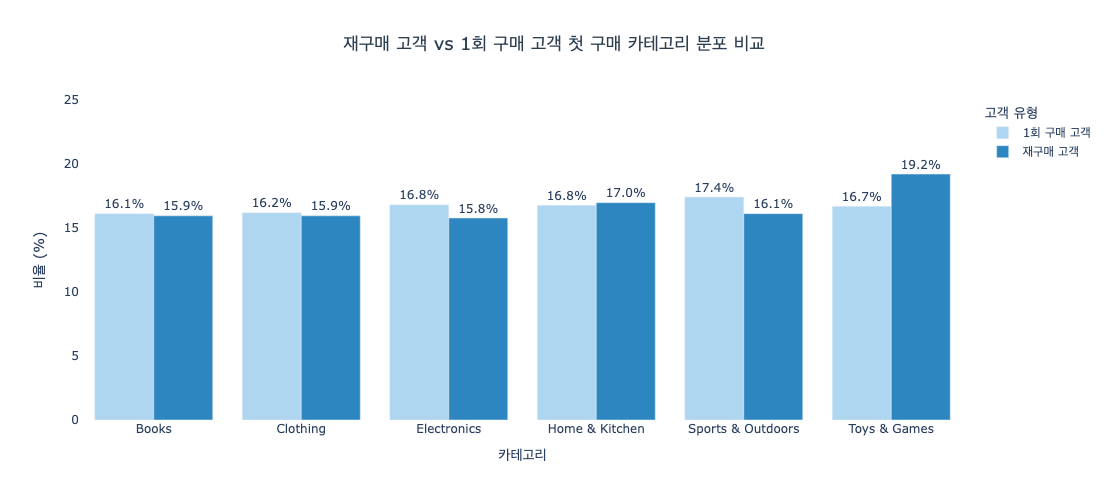

In [16]:
fig = go.Figure()

for ctype, color in zip(['1회 구매 고객', '재구매 고객'], ['#AED6F1', '#2E86C1']):
    data = category_compare[category_compare['customer_type'] == ctype]
    fig.add_trace(go.Bar(
        name=ctype,
        x=data['Category'],
        y=data['비율'],
        text=data['비율'].apply(lambda x: f'{x:.1f}%'),
        textposition='outside',
        marker_color=color
    ))

fig.update_layout(
    title=dict(
        text='재구매 고객 vs 1회 구매 고객 첫 구매 카테고리 분포 비교',
        font=dict(size=18, color='#2c3e50'),
        x=0.5,
        xanchor='center'
    ),
    barmode='group',
    yaxis=dict(title='비율 (%)', range=[0, 25]),
    xaxis=dict(title='카테고리'),
    plot_bgcolor='white',
    height=500,
    width=900,
    legend=dict(title='고객 유형')
)

fig.show()

### 재구매 고객 vs 1회 구매 고객 첫 구매 카테고리 비교

**가설 2**: Silver/Bronze 내 재구매 고객은 1회 구매 고객과 첫 구매 카테고리 분포가 다를 것이다.
- 할인율이 재구매를 설명하지 못함에 따라, 첫 구매 카테고리가 재구매 여부에 영향을 미치는지 확인한다. 특정 카테고리가 재구매의 진입점이 될 가능성을 탐색한다.

---

분석 결과, 두 그룹 모두 전 카테고리에서 **14 ~ 20%** 수준으로 균등하게 분포되어 있으며, 유의미한 차이가 나타나지 않았다. 다만 **Toys & Games** 에서 재구매 고객(19.2%)이 1회 구매 고객(16.7%)보다 **2.5%p** 높게 나타나 상대적으로 재구매 가능성이 높은 카테고리로 확인되었다.

**→ 가설 검증 결과**:
- 전반적인 카테고리 분포 차이는 유의미하지 않아 **가설 2가 기각**되었다. 카테고리 역시 재구매 여부를 설명하지 못함에 따라, 다음으로 **첫 구매 객단가** 관점에서 분석을 진행한다.

In [17]:
# 재구매 고객 vs 1회 구매 고객 첫 구매 객단가 비교
amount_compare = df_sb_first.groupby('customer_type')['TotalAmount'].mean().reset_index()

In [18]:
amount_compare.columns = ['customer_type', 'avg_amount']

In [19]:
amount_compare

,customer_type,avg_amount
0,1회 구매 고객,803.644755
1,재구매 고객,928.144374


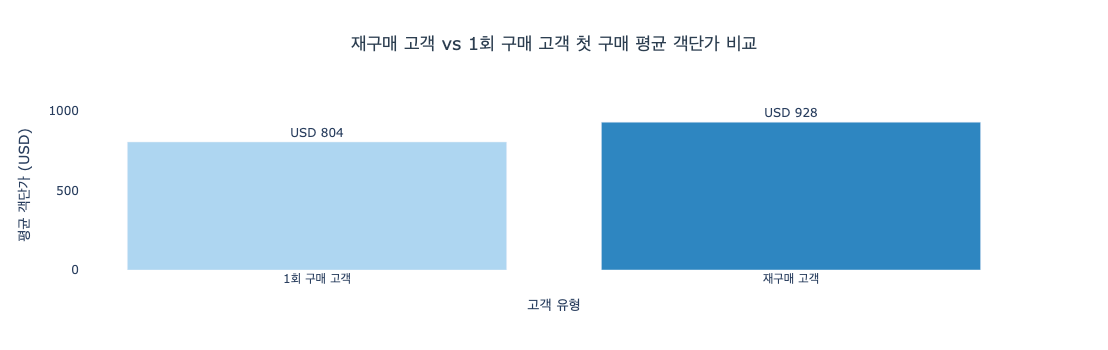

In [25]:
fig = go.Figure(go.Bar(
    x=amount_compare['customer_type'],
    y=amount_compare['avg_amount'],
    marker_color=['#AED6F1', '#2E86C1'],
    text=amount_compare['avg_amount'].apply(lambda x: f'USD {x:,.0f}'),
    textposition='outside'
))

fig.update_layout(
    title=dict(
        text='재구매 고객 vs 1회 구매 고객 첫 구매 평균 객단가 비교',
        font=dict(size=18, color='#2c3e50'),
        x=0.5,
        xanchor='center'
    ),
    yaxis=dict(
        title='평균 객단가 (USD)',
        range=[0, amount_compare['avg_amount'].max()*1.15]
    ),
    xaxis=dict(title='고객 유형'),
    plot_bgcolor='white',
    height=350,
    width=500
)

fig.show()

### 재구매 고객 vs 1회 구매 고객 첫 구매 객단가 비교

**가설 3**: Silver/Bronze 내 재구매 고객은 1회 구매 고객보다 첫 구매 시 객단가가 높을 것이다.
- 카테고리 분포 역시 재구매를 설명하지 못함에 따라, 첫 구매 금액이 클수록 플랫폼에 대한 신뢰나 만족도가 높아 재구매로 이어질 가능성이 있는지 검증한다.

---

분석 결과, 재구매 고객의 첫 구매 평균 객단가(USD 928)가 1회 구매 고객(USD 804)보다 **USD 124 높게** 나타났다.

**→ 가설 검증 결과**:
- 재구매 고객의 첫 구매 객단가가 더 높게 나타나 **가설 3이 채택**되었다. 이는 첫 구매 시 더 높은 금액을 지출한 고객이 플랫폼에 대한 신뢰나 만족도가 높아 재구매로 이어지는 경향이 있음을 시사한다.

---

## 🥈🥉 이탈 위험 고객군 (Silver + Bronze) 솔루션

### 분석 결과 요약

- Silver/Bronze 전체 8,068명 중 재구매 고객은 **583명(7.2%)** 에 불과하며, 나머지 92.8%는 1회 구매에 그침
- 재구매 고객과 1회 구매 고객의 **첫 구매 할인율**(0.075 vs 0.071)은 0.4%p 차이로 유의미하지 않아 **가설 1 기각**
- 재구매 고객과 1회 구매 고객의 **첫 구매 카테고리 분포** 역시 전반적으로 유의미한 차이가 없어 **가설 2 기각**
- 다만 Toys & Games(+2.5%p)에서 재구매 고객 비율이 상대적으로 높고, Sports & Outdoors(-1.3%p)에서 낮은 경향이 관찰됨
- 재구매 고객의 첫 구매 객단가(USD 928)가 1회 구매 고객(USD 804)보다 높아 **가설 3 채택**
- 할인율·카테고리는 재구매를 설명하지 못하지만, **첫 구매 금액이 높은 고객이 재구매로 이어지는 경향** → 초기 관여도가 재구매의 조건이 될 수 있음

---

> ✅ **액션 아이템**
>
> **1. 고관여 첫 구매 고객 리타겟팅 우선화**
> - 첫 구매 금액이 높은 고객(예: USD 800 이상)을 재구매 유도 우선 대상으로 설정
> - 첫 구매 후 **2-4주 시점** 개인화 쿠폰 및 연관 상품 추천 발송
>
> **2. 저관여 첫 구매 고객 관여도 제고**
> - 첫 구매 금액이 낮은 고객 대상 관련 상품 번들 추천·업셀링으로 관여도 자극
> - 누적 구매액 기반 "다음 구매 시 혜택" 알림으로 재방문 동기 부여
>
> **3. Toys & Games 카테고리 집중 프로모션**
> - 재구매 비율이 상대적으로 높은 Toys & Games 첫 구매 고객 대상 후속 쿠폰 발송
> - 시즌 이벤트(크리스마스, 어린이날 등) 연계 재구매 유도 캠페인 진행
>
> **4. Silver 등급 전환 동기 부여**
> - Bronze 고객 대상 **"1회만 더 구매하면 Silver 달성"** 등급 업그레이드 알림 발송
> - Silver 전환 시 즉시 사용 가능한 웰컴 쿠폰 제공으로 재구매 선순환 유도

---

> 🧪 **A/B 테스트 제안**
>
> **🥈🥉 Silver + Bronze 공통**
> - **1**. 첫 구매 금액 기반 리타겟팅 세분화 실험
> > - 가설: 고관여(고액) 첫 구매 고객 대상 집중 리타겟팅이 전체 대상 동일 발송보다 재구매 전환율을 높일 것이다
> > - A그룹: 전체 고객 동일 재구매 유도 쿠폰 발송
> > - B그룹: 첫 구매 금액 상위(USD 800 이상) 고객 우선 집중 발송
> - **주요 지표(Primary KPI)**: 2nd Purchase Conversion Rate(2번째 구매 전환율)
> - **보조 지표(Secondary KPI)**: AOV, ARPU
>
> - **2**. 첫 구매 후 리마인드 타이밍 실험
> > - 가설: 첫 구매 후 빠른 시점(2-4주) 리마인드가 늦은 시점(8-12주)보다 재구매 전환율을 높일 것이다
> > - A그룹: 첫 구매 후 8-12주 시점 재구매 유도 쿠폰 발송
> > - B그룹: 첫 구매 후 2-4주 시점 재구매 유도 쿠폰 발송
> - **주요 지표(Primary KPI)**: 알림 발송 후 30일 내 재구매율, 2nd Purchase Conversion Rate
> - **보조 지표(Secondary KPI)**: 구매까지 걸린 기간, AOV
>
> ---
> - **실험 단위**: 고객 단위 랜덤 할당 (User-level Randomization)
> - **실험 기간**: 첫 구매 후 최소 1-2개월 동안 진행하여 재구매 전환 효과 검증
> - **실험 설계 유의사항**: 동일 고객이 복수 실험에 동시에 노출되지 않도록 실험 간 상호 배타적 그룹으로 분리